<a href="https://colab.research.google.com/github/Nyada56/verbose-octo-pancake/blob/main/HW_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

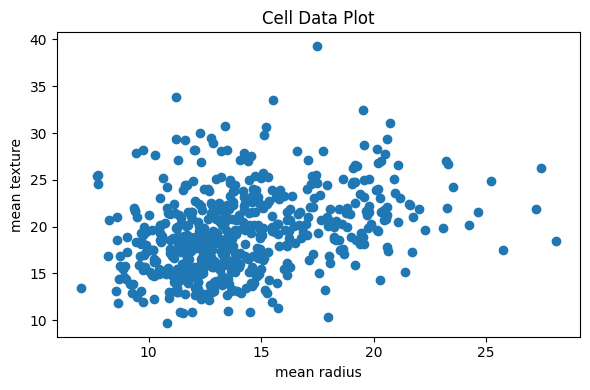

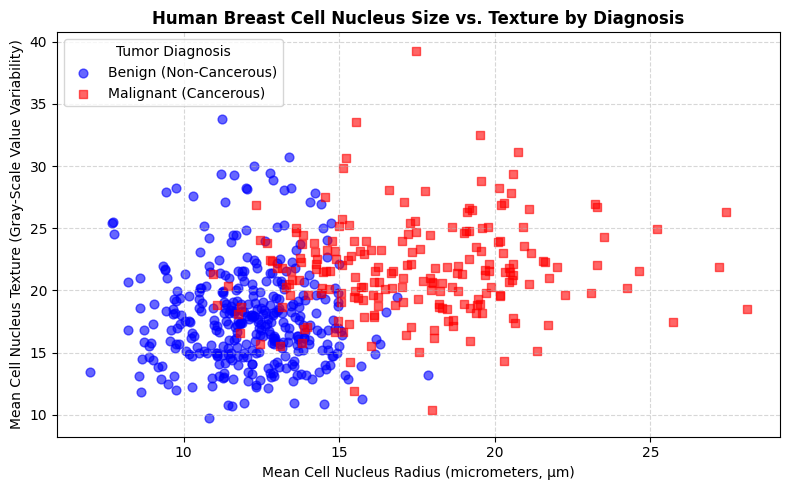

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer

# ==========================================
# 1. LOAD REAL BIOLOGICAL DATASET
# ==========================================
# Load real cell nucleus measurements from scikit-learn
cancer_data = load_breast_cancer(as_frame=True)
df = cancer_data.frame

# Target: 0 = Malignant (Cancerous), 1 = Benign (Non-Cancerous)
df['diagnosis'] = df['target'].map(
    {0: 'Malignant (Cancerous)', 1: 'Benign (Non-Cancerous)'}
)

# Save to CSV so you can upload it to GitHub for your project submission
df.to_csv('breast_cancer_data.csv', index=False)


# ==========================================
# 2. VERSION 1: PRELIMINARY PLOT
# ==========================================
plt.figure(figsize=(6, 4))

# Simple scatter plot of raw cell data
plt.scatter(df['mean radius'], df['mean texture'])

# Basic default titles
plt.title('Cell Data Plot')
plt.xlabel('mean radius')
plt.ylabel('mean texture')

plt.tight_layout()
plt.savefig('cancer_v1.png')
plt.show()


# ==========================================
# 3. VERSION 2: IMPROVED PLOT
# ==========================================
fig, ax = plt.subplots(figsize=(8, 5))

# Define colors and marker styles for diagnosis groups
groups = [
    ('Benign (Non-Cancerous)', 'blue', 'o'),  # Blue circles
    ('Malignant (Cancerous)', 'red', 's'),  # Red squares
]

# Separate data points by medical diagnosis
for label, color, marker in groups:
    subset = df[df['diagnosis'] == label]
    ax.scatter(
        subset['mean radius'],
        subset['mean texture'],
        label=label,
        color=color,
        marker=marker,
        alpha=0.6,  # Transparency to show overlapping points
        s=40,  # Slightly larger marker size
    )

# Clear scientific labels and title
ax.set_title(
    'Human Breast Cell Nucleus Size vs. Texture by Diagnosis',
    fontsize=12,
    fontweight='bold',
)
ax.set_xlabel('Mean Cell Nucleus Radius (micrometers, µm)', fontsize=10)
ax.set_ylabel(
    'Mean Cell Nucleus Texture (Gray-Scale Value Variability)', fontsize=10
)

# Subtle gridlines and clean legend layout
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(title='Tumor Diagnosis', loc='upper left')

plt.tight_layout()
plt.savefig('cancer_v2.png', dpi=300)
plt.show()